La calibrazione di un modello Monte Carlo su un asset finanziario consiste nell'adattare i parametri del modello affinché le simulazioni riproducano il più fedelmente possibile le caratteristiche osservate nei dati reali. Dal punto di vista teorico, la calibrazione permette di stimare parametri come la volatilità, il drift e altri fattori che influenzano la dinamica dei prezzi, utilizzando metodi statistici come la massimizzazione della verosimiglianza o la minimizzazione dell'errore tra i valori simulati e quelli osservati. Tecnicamente, si parte dai dati storici dell'asset, si calcolano statistiche rilevanti (ad esempio, media e deviazione standard dei rendimenti), e si utilizzano questi valori per impostare i parametri del modello Monte Carlo. Successivamente, si eseguono numerose simulazioni e si confrontano i risultati con i dati reali, iterando il processo di calibrazione fino a ottenere una buona corrispondenza tra modello e realtà. Questo processo è fondamentale per garantire che le simulazioni siano utili per la valutazione del rischio, la previsione dei prezzi e la gestione finanziaria.

La calibrazione di un modello Monte Carlo richiede i seguenti passaggi:

1. **Raccolta dati storici**: Acquisire i dati dell’asset finanziario da analizzare.
2. **Calcolo delle statistiche**: Determinare media, volatilità e altre statistiche rilevanti dai dati storici.
3. **Impostazione dei parametri**: Utilizzare le statistiche calcolate per impostare i parametri iniziali del modello (ad esempio drift e volatilità).
4. **Simulazione**: Eseguire numerose simulazioni Monte Carlo utilizzando i parametri scelti.
5. **Confronto con i dati reali**: Valutare la corrispondenza tra i risultati simulati e quelli osservati.
6. **Ottimizzazione**: Modificare iterativamente i parametri per minimizzare la differenza tra simulazioni e dati reali, tramite metodi come la massimizzazione della verosimiglianza o la minimizzazione dell’errore.
7. **Validazione**: Verificare che il modello calibrato sia robusto e rappresenti accuratamente la realtà.

Questi passaggi garantiscono che il modello Monte Carlo sia affidabile per analisi e decisioni finanziarie.

# Maximum Likelihood Estimation (MLE) per la Calibrazione

Una delle tecniche più utilizzate per la calibrazione dei modelli Monte Carlo è la **massimizzazione della verosimiglianza** (Maximum Likelihood Estimation, MLE).

## Quadro Teorico

La MLE consiste nel trovare i parametri del modello che massimizzano la probabilità di osservare i dati storici effettivamente rilevati. Supponiamo che i rendimenti storici $r_1, r_2, \ldots, r_n$ siano modellati come variabili casuali indipendenti e identicamente distribuite secondo una distribuzione parametrica (ad esempio, normale con media $\mu$ e deviazione standard $\sigma$).

La funzione di verosimiglianza è:

$$L(\mu, \sigma) = \prod_{i=1}^n f(r_i \mid \mu, \sigma)$$

dove $f(r_i \mid \mu, \sigma)$ è la funzione di densità della normale:

$$f(r_i \mid \mu, \sigma) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left(-\frac{(r_i - \mu)^2}{2\sigma^2}\right)$$

## Stima dei Parametri

Per trovare i valori ottimali di $\mu$ e $\sigma$, si massimizza la funzione di verosimiglianza (o, più comunemente, il suo logaritmo):

$$\ell(\mu, \sigma) = \log L(\mu, \sigma) = -\frac{n}{2}\log(2\pi) - n\log(\sigma) - \frac{1}{2\sigma^2}\sum_{i=1}^n (r_i - \mu)^2$$

Le stime di massima verosimiglianza sono:

$$\hat{\mu} = \frac{1}{n}\sum_{i=1}^n r_i$$

$$\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (r_i - \hat{\mu})^2$$

Questi valori vengono poi utilizzati come parametri di input per le simulazioni Monte Carlo.

In [10]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

print("Downloading S&P 500 data...")
sp500 = yf.download('^GSPC', period='5y', progress=False)

log_returns = np.diff(np.log(sp500['Close'].values))

mu_hat = np.mean(log_returns)      # Media dei rendimenti log
sigma_hat = np.std(log_returns)    # Deviazione standard dei rendimenti log
S0 = sp500['Close'].values[-1]     # Prezzo attuale

mu_annual = mu_hat * 252  # Rendimento medio annuale
sigma_annual = sigma_hat * np.sqrt(252)  # Volatilità annuale

T = 1         # orizzonte temporale (anni)
N = 252       # numero di passi (giorni)
M = 10**4     # numero di traiettorie

dt = T / N

S = np.zeros((M, N+1))
S[:,0] = S0
for t in range(1, N+1):
    Z = np.random.randn(M)
    S[:,t] = S[:,t-1] * np.exp((mu_hat - 0.5 * sigma_hat**2) * dt + sigma_hat * np.sqrt(dt) * Z)

/Users/alemone/Documents/ALESSIO/CODICE/PY/PM/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/alemone/Documents/ALESSIO/CODICE/PY/PM/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/alemone/Documents/ALESSIO/CODICE/PY/PM/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alemone/Documents/ALESSIO/CODICE/PY/PM/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/alemone/Documents/ALESSIO/CODICE/PY/PM/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in sc


CONFRONTO: PROIEZIONI MONTE CARLO vs DATI STORICI


/Users/alemone/Documents/ALESSIO/CODICE/PY/PM/.venv/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


ValueError: zero-size array to reduction operation minimum which has no identity

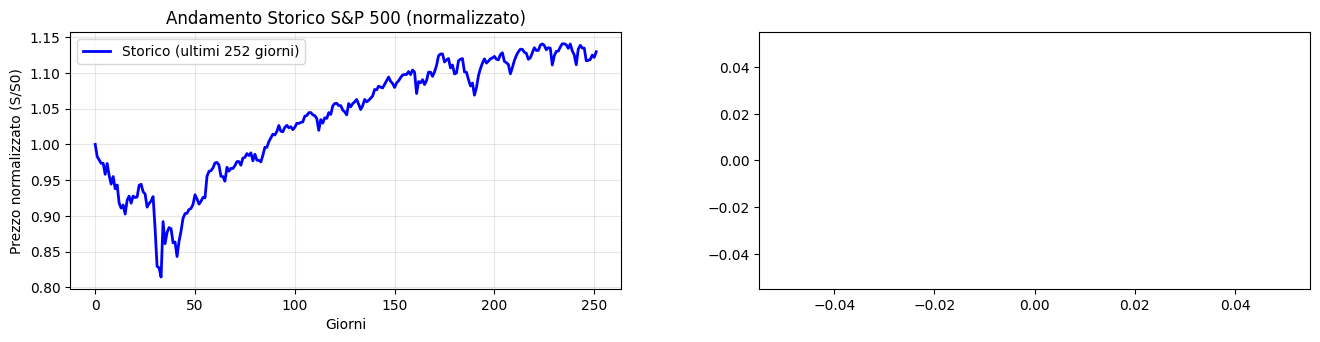

In [12]:
# ============================================================================
# 3. CONFRONTO TRA PROIEZIONI E DATI STORICI
# ============================================================================
print("\n" + "="*70)
print("CONFRONTO: PROIEZIONI MONTE CARLO vs DATI STORICI")
print("="*70)

# Estrai i dati storici passati (ultimi N giorni disponibili)
historical_prices = sp500['Close'].values[-N:]
historical_dates_numeric = np.arange(len(historical_prices))

# Normalizza i dati storici al prezzo iniziale per il confronto
historical_prices_normalized = historical_prices / historical_prices[0]
S_final_normalized = S / S0  # Normalizza anche le simulazioni

# Estrai statistiche dalle simulazioni
mean_projection = np.mean(S_final_normalized, axis=0)
percentile_5_proj = np.percentile(S_final_normalized, 5, axis=0)
percentile_95_proj = np.percentile(S_final_normalized, 95, axis=0)
percentile_25_proj = np.percentile(S_final_normalized, 25, axis=0)
percentile_75_proj = np.percentile(S_final_normalized, 75, axis=0)
time_steps_proj = np.arange(N+1)

# Crea una figura con più subplots
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.25)

# ---- Plot 1: Dati storici (ultimi N giorni) ----
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(historical_dates_numeric, historical_prices_normalized, 'b-', linewidth=2, label='Storico (ultimi {} giorni)'.format(N))
ax1.set_title('Andamento Storico S&P 500 (normalizzato)')
ax1.set_xlabel('Giorni')
ax1.set_ylabel('Prezzo normalizzato (S/S0)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ---- Plot 2: Distribuzione rendimenti storici vs teorica ----
ax2 = fig.add_subplot(gs[0, 1])
log_returns_hist = np.diff(np.log(historical_prices))
ax2.hist(log_returns_hist, bins=40, density=True, alpha=0.7, color='blue', edgecolor='black', label='Storico')
# Sovrapponi la normale teorica
x_hist = np.linspace(log_returns_hist.min(), log_returns_hist.max(), 100)
y_hist = stats.norm.pdf(x_hist, loc=mu_hat, scale=sigma_hat)
ax2.plot(x_hist, y_hist, 'r-', linewidth=2, label='Normale stimata')
ax2.set_title('Distribuzione dei rendimenti (dati storici)')
ax2.set_xlabel('Rendimento log giornaliero')
ax2.set_ylabel('Densità')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# ---- Plot 3: Proiezioni vs Storico ----
ax3 = fig.add_subplot(gs[1, :])
# Plotta un sottoinsieme di traiettorie simulate (trasparenti)
n_show = min(200, M)
indices_show = np.random.choice(M, size=n_show, replace=False)
ax3.plot(time_steps_proj, S_final_normalized[indices_show, :].T, alpha=0.1, color='blue', linewidth=0.5, label=f'{n_show} traiettorie MC')

# Sovrapponi medie e percentili
ax3.plot(time_steps_proj, mean_projection, 'r-', linewidth=3, label='Media proiezioni')
ax3.fill_between(time_steps_proj, percentile_5_proj, percentile_95_proj, alpha=0.15, color='red', label='90% conf. (5%-95%)')
ax3.fill_between(time_steps_proj, percentile_25_proj, percentile_75_proj, alpha=0.25, color='orange', label='50% conf. (25%-75%)')

# Aggiungi i dati storici come punto di partenza
ax3.plot(historical_dates_numeric, historical_prices_normalized, 'g-', linewidth=2.5, label='Storico (ultimi {} giorni)'.format(N), alpha=0.8)
ax3.axvline(x=N, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Oggi (inizio proiezione)')

ax3.set_title('Confronto: Dati Storici + Proiezioni Monte Carlo (Next {} giorni)'.format(N), fontsize=12, fontweight='bold')
ax3.set_xlabel('Giorni (0={} giorni fa, {}=Oggi, {}+=Proiezioni future)'.format(N, N, N+1))
ax3.set_ylabel('Prezzo normalizzato (S/S0)')
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)

# ---- Plot 4: Distribuzione prezzi finali con valori storici ----
ax4 = fig.add_subplot(gs[2, 0])
S_final = S[:, -1]
ax4.hist(S_final, bins=60, density=True, alpha=0.7, color='blue', edgecolor='black', label='Proiezioni MC')

# Sovrapponi distribuzione log-normale teorica
S_final_sorted = np.sort(S_final)
mean_log = np.log(S0) + (mu_hat - 0.5 * sigma_hat**2) * T
std_log = sigma_hat * np.sqrt(T)
x_range = np.linspace(S_final_sorted.min(), S_final_sorted.max(), 100)
pdf_lognormal = stats.lognorm.pdf(x_range, s=std_log, scale=np.exp(mean_log))
ax4.plot(x_range, pdf_lognormal, 'r-', linewidth=2.5, label='Lognormale teorica')
ax4.axvline(S0, color='green', linestyle='--', linewidth=2, label=f'Prezzo attuale: ${S0:.2f}')
ax4.axvline(np.mean(S_final), color='orange', linestyle='--', linewidth=2, label=f'Media proiezioni: ${np.mean(S_final):.2f}')

ax4.set_title('Distribuzione dei prezzi finali')
ax4.set_xlabel('Prezzo finale ($)')
ax4.set_ylabel('Densità')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

# ---- Plot 5: Volatilità realizzata vs parametri stimati ----
ax5 = fig.add_subplot(gs[2, 1])
# Calcola la volatilità realizzata su finestre di 21 giorni (1 mese)
window = 21
realized_vol = []
for i in range(0, len(log_returns_hist) - window, window):
    vol_window = np.std(log_returns_hist[i:i+window]) * np.sqrt(252)
    realized_vol.append(vol_window)

dates_vol = np.arange(0, len(realized_vol) * window, window)
ax5.plot(dates_vol, realized_vol, 'b-', linewidth=2, marker='o', markersize=4, label='Volatilità realizzata (finestre 21gg)')
ax5.axhline(y=sigma_annual, color='r', linestyle='--', linewidth=2.5, label=f'Volatilità stimata (MLE): {sigma_annual:.4f}')
ax5.axhline(y=np.std(log_returns_hist) * np.sqrt(252), color='orange', linestyle=':', linewidth=2, label=f'Volatilità totale: {np.std(log_returns_hist) * np.sqrt(252):.4f}')

ax5.set_title('Volatilità: Realizzata vs Stimata')
ax5.set_xlabel('Giorni')
ax5.set_ylabel('Volatilità annualizzata')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

plt.suptitle('Analisi Completa: Dati Storici vs Proiezioni Monte Carlo (S&P 500)', 
             fontsize=14, fontweight='bold', y=0.995)

plt.show()

# ---- Statistiche di confronto ----
print(f"\nStatistiche dei dati storici (ultimi {N} giorni):")
print(f"  Prezzo iniziale:                 ${historical_prices[0]:.2f}")
print(f"  Prezzo finale:                   ${historical_prices[-1]:.2f}")
print(f"  Rendimento storico:              {((historical_prices[-1] / historical_prices[0] - 1) * 100):.2f}%")
print(f"  Volatilità realizzata (annuale): {np.std(log_returns_hist) * np.sqrt(252):.4f}")

print(f"\nStatistiche delle proiezioni Monte Carlo (prossimi {N} giorni):")
print(f"  Prezzo iniziale:                 ${S0:.2f}")
print(f"  Prezzo medio atteso:             ${np.mean(S_final):.2f}")
print(f"  Rendimento atteso:               {((np.mean(S_final) / S0 - 1) * 100):.2f}%")
print(f"  Intervallo 90% (5%-95%):         [${np.percentile(S_final, 5):.2f}, ${np.percentile(S_final, 95):.2f}]")
print(f"  Volatilità proiettata (annuale): {sigma_annual:.4f}")

print(f"\nParametri stimati (MLE da 5 anni di dati):")
print(f"  Drift giornaliero (μ):           {mu_hat:.6f}")
print(f"  Volatilità giornaliera (σ):      {sigma_hat:.6f}")
print(f"  Drift annuale:                   {mu_annual:.6f} ({mu_annual*100:.2f}%)")
print(f"  Volatilità annuale:              {sigma_annual:.6f} ({sigma_annual*100:.2f}%)")

print("\n" + "="*70)